# Home Credit · Model stability review
**Alvaro Mendizabal · Development benchmark · Phase 5B**

Which model keeps its credit-risk ranking useful as the population changes over time?
This review uses **727,187 held-out development predictions per model**, from four model
families and five expanding temporal folds. All source predictions were hash verified.
No model is fitted here; the final holdout (weeks 73–91) remains locked.

The notebook includes executed tables and static figures for GitHub viewing.
The companion [interactive benchmark report](../reports/benchmark/report.html) provides hover details.
The [validation record](../reports/benchmark/VALIDATION.md) documents tests and limitations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

from home_credit.modeling.report import COLORS, LABELS
from home_credit.modeling.review import load_review

%matplotlib inline

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/benchmark_review.json").is_file()
)
evidence, review = load_review(ROOT)
models = pd.DataFrame(review["models"])
folds = pd.DataFrame(review["folds"])
weekly = pd.DataFrame(evidence["weekly_metrics"])
population = pd.DataFrame(review["weekly_population"])
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.titlelocation": "left",
    }
)


def show_table(frame, decimals=5):
    display(HTML(frame.to_html(index=False, border=0, float_format=lambda x: f"{x:.{decimals}f}")))


print(
    f"Accepted: {evidence['model_folds']} model folds; "
    f"{evidence['oof_rows_per_model']:,} OOF cases per model"
)
print(
    f"Prediction weeks: {evidence['oof_week_min']}-{evidence['oof_week_max']}; holdout "
    f"remains locked"
)
print(f"Source summary SHA-256: {review['summary_sha256']}")

Accepted: 20 model folds; 727,187 OOF cases per model
Prediction weeks: 33-72; holdout remains locked
Source summary SHA-256: cb87d1ce0abd7419a115e3b47aa1d332aad27f4d476a36a0028c2c7b2af183f4


## 1. The metric determines the decision
The [official competition evaluation](https://www.kaggle.com/competitions/home-credit-credit-risk-model-stability/overview/evaluation) is:

**stability = mean(weekly Gini) + 88 × min(0, slope) − 0.5 × residual standard deviation**,
where weekly Gini = 2 × ROC AUC − 1. Higher is better.

Our predeclared development objective averages the **five fold scores equally**.
Applying the formula to all pooled OOF weeks is a separate diagnostic; it does not replace that objective.
Penalties must be calculated inside each fold before averaging.

**Metric audit:** the archived evaluator clipped probabilities before all metrics. Clipping extreme
predictions changes ties in the logistic baseline. This review recalculates Gini, ROC AUC, and
average precision from **unclipped predictions**, and Brier from raw probabilities. Only log loss
uses the explicit `[1e-7, 1−1e-7]` clipping convention. The immutable original acceptance record
is retained. The three boosting models' stability scores and their ordering are unchanged.

In [2]:
comparison = models[
    [
        "model",
        "mean_fold_stability",
        "archived_mean_fold_stability",
        "oof_stability_score",
        "oof_auc",
        "oof_pr_auc",
        "oof_brier_score",
        "oof_log_loss",
    ]
].copy()
comparison["model"] = comparison["model"].map(LABELS)
comparison.columns = [
    "Model",
    "Mean fold stability ↑",
    "Archived mean ↑",
    "Pooled stability ↑",
    "OOF ROC AUC ↑",
    "OOF AP ↑",
    "OOF Brier ↓",
    "OOF log loss ↓",
]
show_table(comparison)
leader = models.iloc[0]
margin = leader["mean_fold_stability"] - models.iloc[1]["mean_fold_stability"]
display(
    Markdown(
        f"**{LABELS[leader['model']]} leads** by {margin:.5f} mean-fold stability points. "
        f"These are development results after early stopping and family comparison; the "
        f"margin is not a confidence interval."
    )
)

Model,Mean fold stability ↑,Archived mean ↑,Pooled stability ↑,OOF ROC AUC ↑,OOF AP ↑,OOF Brier ↓,OOF log loss ↓
LightGBM,0.58519,0.58519,0.67887,0.84689,0.20452,0.03243,0.12680
XGBoost,0.55889,0.55889,0.67817,0.84658,0.20470,0.03244,0.12689
CatBoost,0.54633,0.54633,0.67116,0.84275,0.20116,0.03251,0.12774
Logistic SGD,-0.12099,-0.12048,0.36078,0.67562,0.10262,0.03635,0.25383


**LightGBM leads** by 0.02630 mean-fold stability points. These are development results after early stopping and family comparison; the margin is not a confidence interval.

ROC AUC describes ranking across all thresholds. **AP (average precision)** is useful for the
minority default class and is explicitly distinguished from trapezoidal PR AUC. **Brier score and
log loss** evaluate the probabilities themselves. Accuracy or F1 at an arbitrary 0.5 threshold
would obscure the class imbalance; operating thresholds require a declared decision cost or capacity.

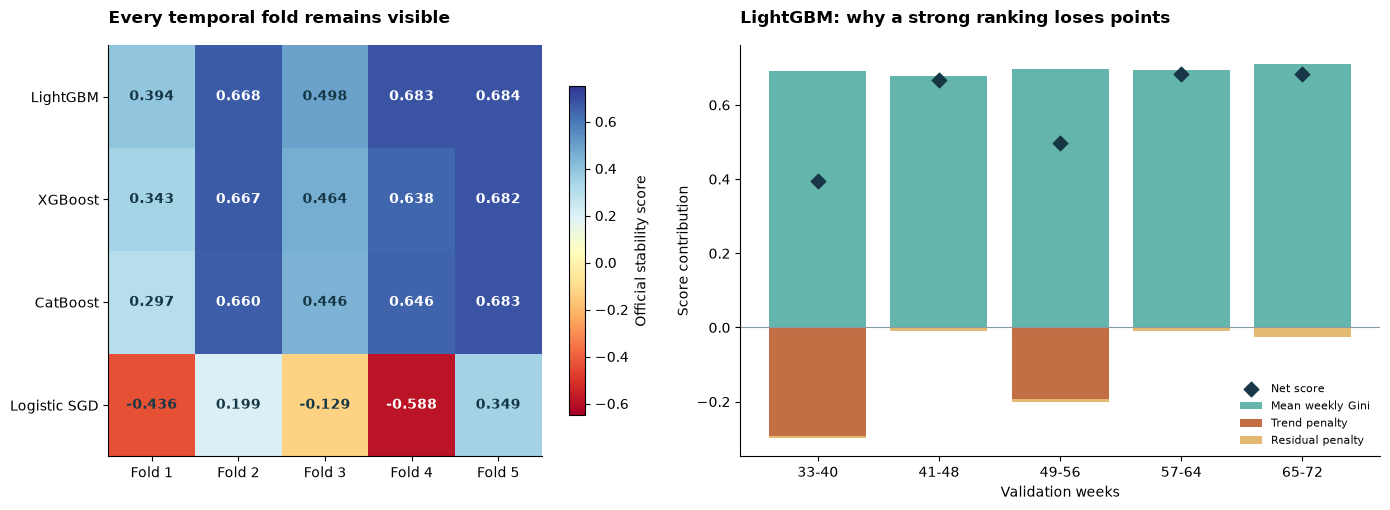

In [3]:
names = models["model"].tolist()
matrix = folds.pivot(index="model", columns="fold", values="stability_score").loc[names]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.1, 1.3]})
im = axes[0].imshow(matrix, cmap="RdYlBu", vmin=-0.65, vmax=0.75, aspect="auto")
axes[0].set_yticks(range(4), [LABELS[n] for n in names])
axes[0].set_xticks(range(5), [f"Fold {i}" for i in range(1, 6)])
axes[0].set_title("Every temporal fold remains visible", pad=16, fontweight="bold")
for i in range(4):
    for j in range(5):
        axes[0].text(
            j,
            i,
            f"{matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            color="white" if abs(matrix.iloc[i, j]) > 0.53 else "#153746",
            fontweight="bold",
        )
fig.colorbar(im, ax=axes[0], label="Official stability score", shrink=0.8)
lf = folds[folds["model"] == leader["model"]]
x = np.arange(1, 6)
axes[1].bar(x, lf["mean_gini"], color="#64b6ac", label="Mean weekly Gini")
axes[1].bar(x, lf["slope_penalty"], color="#c46e46", label="Trend penalty")
axes[1].bar(
    x, lf["residual_penalty"], bottom=lf["slope_penalty"], color="#e4ba73", label="Residual penalty"
)
axes[1].scatter(
    x, lf["stability_score"], color="#173746", marker="D", s=55, zorder=5, label="Net score"
)
axes[1].axhline(0, color="#899ba4", linewidth=0.8)
axes[1].set_xticks(x, [f"{int(r.week_min)}-{int(r.week_max)}" for r in lf.itertuples()])
axes[1].set_xlabel("Validation weeks")
axes[1].set_ylabel("Score contribution")
axes[1].set_title("LightGBM: why a strong ranking loses points", pad=16, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

In [4]:
weakest = lf.sort_values("stability_score").iloc[0]
show_table(
    lf[
        [
            "fold",
            "week_min",
            "week_max",
            "rows",
            "positives",
            "mean_gini",
            "slope_penalty",
            "residual_penalty",
            "stability_score",
        ]
    ]
)
display(
    Markdown(
        f"**Fold {int(weakest['fold'])}, weeks "
        f"{int(weakest['week_min'])}-{int(weakest['week_max'])}, is the leader's weakest "
        f"period.** Its mean Gini of {weakest['mean_gini']:.4f} loses "
        f"{abs(weakest['slope_penalty']):.4f} points to deterioration and "
        f"{abs(weakest['residual_penalty']):.4f} to residual variation. Tuning should "
        f"therefore target stability in this period, not merely pooled AUC."
    )
)

fold,week_min,week_max,rows,positives,mean_gini,slope_penalty,residual_penalty,stability_score
1,33,40,182576,6105,0.69113,-0.29252,-0.00493,0.39368
2,41,48,194116,7165,0.67843,0.00000,-0.01070,0.66772
3,49,56,192561,7191,0.69754,-0.19255,-0.00716,0.49782
4,57,64,126970,5936,0.69327,0.00000,-0.01047,0.68281
5,65,72,30964,699,0.71069,0.00000,-0.02679,0.68391


**Fold 1, weeks 33-40, is the leader's weakest period.** Its mean Gini of 0.6911 loses 0.2925 points to deterioration and 0.0049 to residual variation. Tuning should therefore target stability in this period, not merely pooled AUC.

## 2. Population support and temporal change
Each week contributes equally to the competition score, despite different sample counts.
The following views expose both positive rates and the amount of evidence underlying the weekly Gini.

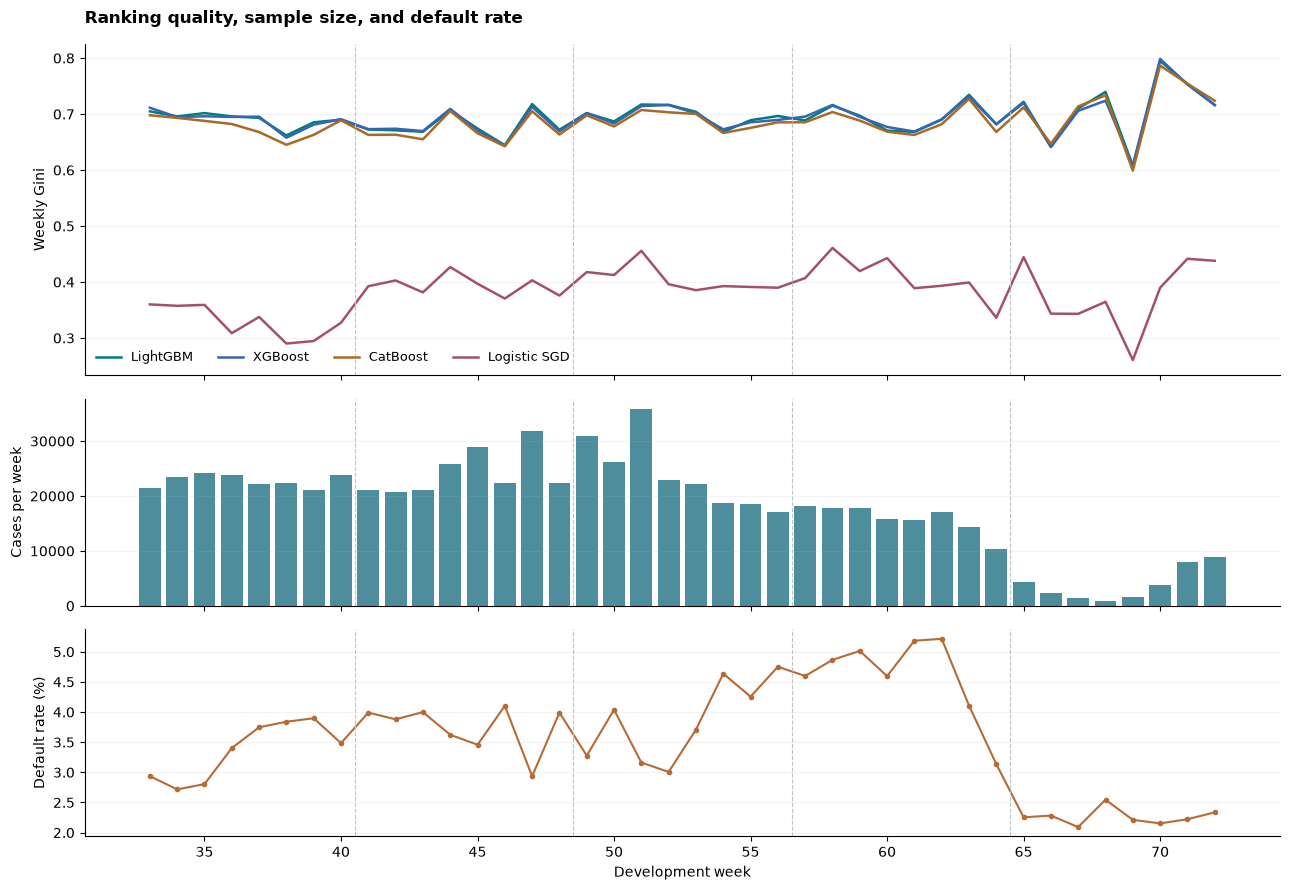

fold,rows,positives,positive_rate
1,182576,6105,0.0334
2,194116,7165,0.0369
3,192561,7191,0.0373
4,126970,5936,0.0468
5,30964,699,0.0226


In [5]:
fig, axes = plt.subplots(
    3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [1.6, 1, 1]}
)
for name in names:
    w = weekly[weekly["model"] == name].sort_values("week_num")
    axes[0].plot(w["week_num"], w["gini"], label=LABELS[name], color=COLORS[name], linewidth=1.8)
axes[0].set_title("Ranking quality, sample size, and default rate", fontweight="bold", pad=15)
axes[0].set_ylabel("Weekly Gini")
axes[0].legend(ncol=4, loc="lower left", frameon=False, fontsize=9)
axes[1].bar(population["week_num"], population["rows"], color="#4e8e9c", width=0.8)
axes[1].set_ylabel("Cases per week")
axes[2].plot(
    population["week_num"],
    100 * population["positive_rate"],
    color="#b66b36",
    marker="o",
    markersize=3,
)
axes[2].set_ylabel("Default rate (%)")
axes[2].set_xlabel("Development week")
for ax in axes:
    for boundary in [40.5, 48.5, 56.5, 64.5]:
        ax.axvline(boundary, color="#b8c6cc", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.15)
fig.tight_layout()
plt.show()
show_table(lf[["fold", "rows", "positives", "positive_rate"]], decimals=4)

The last fold has substantially fewer cases. High residual variability in later weeks should be
interpreted alongside these counts. Fold variation is descriptive temporal variation, not an iid
confidence interval. A future uncertainty analysis must respect weekly dependence.

## 3. Probability quality and calibration
Calibration is assessed from saved predictions using fixed probability bins. Sparse bins carry less
information. These models are not recalibrated here; fitting a calibrator to these same outcomes and
reporting its in-sample improvement would be misleading.

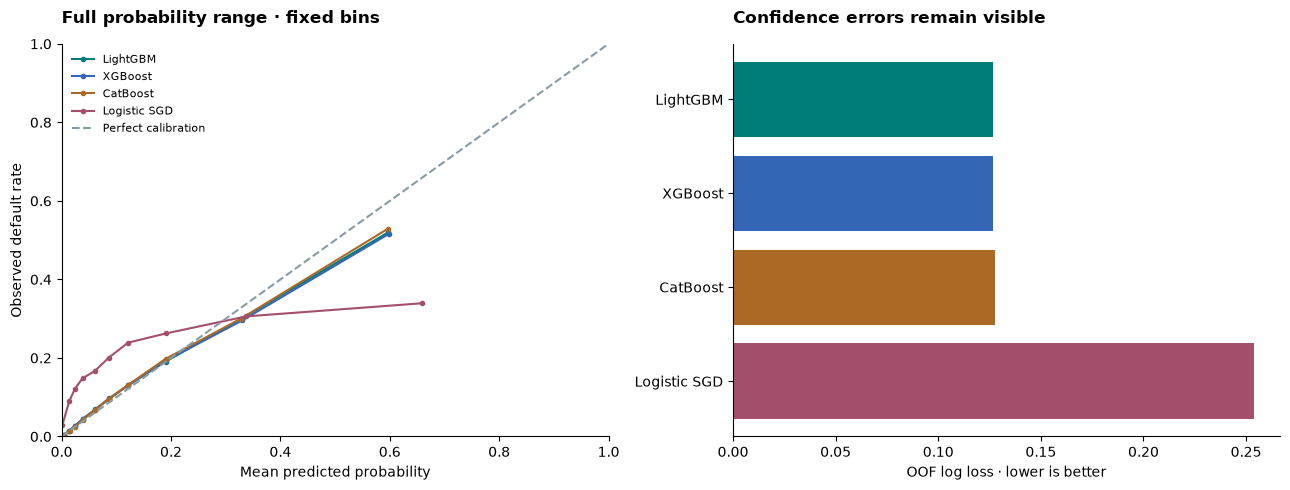

OOF default prevalence / descriptive AP reference: 0.03726
Descriptive constant-probability Brier reference: 0.03587
References use the observed OOF prevalence for context; they are not trained deployable baselines.


In [6]:
calibration = pd.DataFrame(evidence["calibration"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in names:
    c = calibration[calibration["model"] == name]
    axes[0].plot(
        c["prediction_mean"],
        c["observed_rate"],
        marker="o",
        markersize=3,
        color=COLORS[name],
        label=LABELS[name],
    )
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#899ba4", label="Perfect calibration")
axes[0].set(
    xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability", ylabel="Observed default rate"
)
axes[0].set_title("Full probability range · fixed bins", fontweight="bold", pad=15)
axes[0].legend(fontsize=8, frameon=False)
axes[1].barh(
    [LABELS[n] for n in names][::-1],
    models["oof_log_loss"].to_numpy()[::-1],
    color=[COLORS[n] for n in names][::-1],
)
axes[1].set_xlabel("OOF log loss · lower is better")
axes[1].set_title("Confidence errors remain visible", fontweight="bold", pad=15)
fig.tight_layout()
plt.show()
print(f"OOF default prevalence / descriptive AP reference: {evidence['oof_positive_rate']:.5f}")
print(
    f"Descriptive constant-probability Brier reference: "
    f"{evidence['descriptive_constant_brier']:.5f}"
)
print(
    "References use the observed OOF prevalence for context; they are not trained "
    "deployable baselines."
)

## 4. Feature drift: what is known and what remains to investigate
The adversarial screening AUC measures how easily the screening sample's early and late periods
can be distinguished. It is **not** default-prediction accuracy and does not, by itself, establish leakage.
Aggregate results cannot identify the causal source of the shift or substitute for feature lineage review.

In [7]:
print(f"Adversarial screening AUC: {review['screening_drift_auc']:.6f}")
blocks = pd.DataFrame(
    sorted(review["selected_features_by_block"].items(), key=lambda x: (-x[1], x[0])),
    columns=["Feature block", "Selected features"],
)
show_table(blocks)
print(
    f"Boosting feature count: {evidence['selected_features']}; logistic baseline: "
    f"{evidence['model_feature_counts']['linear_logistic']}"
)

Adversarial screening AUC: 0.998944


Feature block,Selected features
credit_bureau_a_depth1,244
applprev_depth1,175
static_depth0,107
person_depth1,69
credit_bureau_a_depth2,29
static_cb_depth0,23
tax_registry_c_depth1,18
applprev_depth2,9
credit_bureau_b_depth1,7
person_depth2,7


Boosting feature count: 700; logistic baseline: 256


## 5. Controlled next experiments

| Order | Experiment | Evidence required before promotion |
|---|---|---|
| 1 | Audit the highest-drift feature blocks on development weeks | Per-week missingness, category coverage, raw feature availability, and adversarial feature importance; preserve the exclusion list. |
| 2 | LightGBM and XGBoost regularization/complexity tuning | Same five folds and raw-prediction evaluator; store every trial's parameters, seed, predictions, metrics, fit time, and immutable input/code identities. |
| 3 | Feature-block ablations and recency weighting | One change per experiment; compare all five paired fold results, especially weeks 33–40 and 49–56. |
| 4 | Ensemble and probability calibration | Fit weights/calibrators using earlier development periods and assess on later ones; report stability, AP, Brier, and log loss. |
| 5 | Freeze the candidate, then unlock the final holdout once | Record the chosen configuration before evaluation; no feedback from holdout into tuning. |

No tuning job is launched by this notebook. Full training must use durable model-fold/trial checkpoints;
completed artifacts must pass identity and checksum checks before reuse. Logs carry UTC timestamps,
heartbeats, stage durations, and total runtime. Reports and source keep their canonical filenames.

## Reproduction and limits
Run `uv run --locked python scripts/review_model_benchmark.py` from the repository root.
Add `--benchmark-dir artifacts/benchmark_acceptance` to recheck the original saved predictions,
or `--force` to execute every notebook cell again. A successful run is reused only if source,
locked dependencies, input evidence, and notebook output hashes still match. Failed execution leaves
the previous successful notebook intact. The inexpensive notebook restarts after an interrupted cell;
model training and completed downloads are never invoked by it.

**Established:** artifact integrity, reproducible development metrics, visible fold weaknesses,
and successful execution of this analysis. **Still pending:** feature-level drift/lineage audit,
controlled tuning, uncertainty quantification, calibration validation, final holdout evaluation,
and any claim about production deployment, fairness, or lending outcomes.

Sources: [official competition metric](https://www.kaggle.com/competitions/home-credit-credit-risk-model-stability/overview/evaluation),
[accepted evidence](../reports/benchmark/acceptance.json), [raw-prediction metric audit](../reports/benchmark/metrics.json),
[locked validation protocol](../configs/validation_protocol.json).